In this notebook, I want to concatenate the metacell output for each condition. 

In [2]:
# Import packages
import os
import pandas as pd
import re
import numpy as np
import glob
from pathlib import Path
from scipy import sparse
from copy import deepcopy
import csv
import itertools
import warnings
import scanpy as sc
from cellbender.remove_background.downstream import anndata_from_h5
import doubletdetection
from sklearn.utils import shuffle
from anndata import AnnData
import anndata
import SEACells
import scipy.sparse as sps
import matplotlib as plt
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# This is the original, concatenated adata
adata = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/concatenated/concatenated.013024/adata.combined.013024.h5ad')


In [4]:
adata

AnnData object with n_obs × n_vars = 53458 × 31874
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log10GenesPerUMI', 'Sample', 'original_total_counts', 'log10_original_total_counts', 'mito_frac'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ribo', 'n_cells'
    obsm: 'gene_expression_encoding'

In [5]:
# Append all the adata from metacells
metacells_dir = "/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/metacells/metacells.020124/"

# Concatenate all the metacell data where MC = 15
# I don't remember why 15 is optimal.
target_mc = 15
sample_description_file = "/data/chanjlab/CRC_ZFP36L2.092023/Organoid/scripts/organoid_analysis_pipeline_scripts/organoid_sample_description.txt"

# Read the sample description file into a DataFrame
sample_description = pd.read_csv(sample_description_file, sep='\t', header=0)

# List to store AnnData objects
adata_list = []

for sample_dir in glob.glob(os.path.join(metacells_dir, "*", str(target_mc))):
    if os.path.isdir(sample_dir):
        #print(f"Processing directory: {sample_dir}")
        h5ad_files = glob.glob(os.path.join(sample_dir, "*.h5ad"))
        for h5ad_file in h5ad_files:
            #print(h5ad_file)

            sample = os.path.basename(h5ad_file).split('.')[1]
            #print(sample)
            adata_tmp = sc.read_h5ad(h5ad_file)
            adata_tmp.obs_names = sample + '_' + adata_tmp.obs_names
            #print(adata_tmp.obs_names)
            
            # Extract the patient from the sample name and add it as a new column to adata.obs
            patient_info = sample.split('_')[0]
            adata_tmp.obs['Patient'] = patient_info
            
            # Extract the tumor information from the sample name and map it to "Metastatic" or "Primary"
            tumor_info = sample.split('_')[1]
            tumor_type = "Metastatic" if tumor_info == "M" else "Primary"
            adata_tmp.obs['Tumor_Site'] = tumor_type
            
            # Extract the culture media from the sample name and add it as a new column to adata.obs
            culture_media_info = sample.split('_')[2]
            if "BASE" in culture_media_info:
                culture_media = "BASE"
            elif "HISC" in culture_media_info:
                culture_media = "HISC"
            elif "Dediff" in culture_media_info:
                culture_media = "Dedifferentiated"            
            adata_tmp.obs['Culture_Media'] = culture_media
            
            # Extract the zfp expression from the sample name and add it as a new column to adata.obs
            zfp_info = sample.split('_')[3]
            adata_tmp.obs['ZFP_Expression'] = zfp_info
            
            # Add a new column 'Sample_Name' with the sample name
            adata_tmp.obs['Sample_Name'] = sample
            
            # Add a new column 'Batch' by mapping the Batch information from the sample description file
            batch_info = sample_description[sample_description['Sample'] == sample]['Batch'].values
            #print(batch_info)
            adata_tmp.obs['Batch'] = batch_info[0]
                     
            # Read each AnnData file and append to the list
            adata_list.append(adata_tmp)

#print(len(adata_list))

In [7]:
# Concatenate the adata_list and ensure unique var_names
combined_adata = anndata.concat(adata_list, axis=0, join='outer')
combined_adata.var_names_make_unique()

# Shuffle the indices
shuffled_indices = np.arange(combined_adata.shape[0])
np.random.shuffle(shuffled_indices)

# Apply the shuffled indices to the combined AnnData object
combined_adata = combined_adata[shuffled_indices, :]
combined_adata

View of AnnData object with n_obs × n_vars = 3404 × 31874
    obs: 'Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression', 'Sample_Name', 'Batch'
    layers: 'raw'

In [44]:
adata = sc.read_h5ad("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/postprocess_adata/postprocess_adata.020524/adata.combined.postprocess.h5ad")

In [46]:
adata.X

<51140x31596 sparse matrix of type '<class 'numpy.float64'>'
	with 164051919 stored elements in Compressed Sparse Row format>

In [9]:
# Look at the raw layer in the concatenated adata
combined_adata.layers['raw']

<3404x31874 sparse matrix of type '<class 'numpy.float64'>'
	with 33657580 stored elements in Compressed Sparse Row format>

In [10]:
# Check that the combined adata is properly shuffled and concatenated
combined_adata.obs

,Patient,Tumor_Site,Culture_Media,ZFP_Expression,Sample_Name,Batch
146_P_HISC_CTRL_1_SEACell-125,146,Primary,HISC,CTRL,146_P_HISC_CTRL_1,6
146_P_HISC_CTRL_1_SEACell-9,146,Primary,HISC,CTRL,146_P_HISC_CTRL_1,6
146_P_BASE_CTRL_1_SEACell-52,146,Primary,BASE,CTRL,146_P_BASE_CTRL_1,5
146_M_BASE_CTRL_1_SEACell-109,146,Metastatic,BASE,CTRL,146_M_BASE_CTRL_1,2
146_P_Dediff_ZFPKD_1_SEACell-35,146,Primary,Dedifferentiated,ZFPKD,146_P_Dediff_ZFPKD_1,8
...,...,...,...,...,...,...
146_M_BASE_ZFPKD_2_SEACell-114,146,Metastatic,BASE,ZFPKD,146_M_BASE_ZFPKD_2,2
146_P_Dediff_ZFPKD_2_SEACell-138,146,Primary,Dedifferentiated,ZFPKD,146_P_Dediff_ZFPKD_2,8
146_P_BASE_CTRL_1_SEACell-125,146,Primary,BASE,CTRL,146_P_BASE_CTRL_1,5
146_P_Dediff_CTRL_1_SEACell-168,146,Primary,Dedifferentiated,CTRL,146_P_Dediff_CTRL_1,8


In [11]:
# Save the combined adata object
#combined_adata.write_h5ad(os.path.join(out_dir, 'combined_adata.h5'))
out_dir = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/metacells/metacells.020524/'
os.makedirs(out_dir,exist_ok=True)

combined_adata.write_h5ad(out_dir + 'adata.combined.h5ad')
combined_adata.obs.to_csv(out_dir + 'obs.combined.csv', sep ='\t')

/home/forsythb/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1294: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/forsythb/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1294: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/forsythb/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1294: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/forsythb/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1294: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/forsythb/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1294: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


## Do Post-Processing on MetaCell Data

In [12]:
# Read in the combined adata
adata_metacells = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/metacells/metacells.020524/adata.combined.h5ad')

In [18]:
adata_metacells.X

<3404x31874 sparse matrix of type '<class 'numpy.float64'>'
	with 33657580 stored elements in Compressed Sparse Row format>

In [47]:
# Create a counts layer
adata.layers["counts"] = adata.X.copy()

In [49]:
adata.layers['counts']

<51140x31596 sparse matrix of type '<class 'numpy.float64'>'
	with 164051919 stored elements in Compressed Sparse Row format>

In [50]:
# Extract the count matrix, barcodes, and genes from the adata
norm_df = adata.X.toarray()
bc = adata.obs_names
g = adata.var_names
norm_df = pd.DataFrame(norm_df, index=bc, columns=g)

In [54]:
adata.layers["raw"] = adata.X.copy()

In [51]:
norm_df.head()

gene_name,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2ML1-AS2,A3GALT2,A4GALT,...,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1
146P_HISC_shCTRL_CCGGACACACCACATA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
146P_dedifferentiation_shZFP36L2_3_ACTTTGTTCGCTGTTC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
KG146Li_BASE_shZFP36L2_3_GTGGTTAGTTGGGAAC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
146P_dedifferentiation_shCtrl_GGGTCTGTCGATGCTA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
146P_HISC_shZFP36L2_3_TGGAACTCAACCTAAC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [52]:
# Convert sparse matrix to dense matrix
adata.X = adata.X.toarray()

In [24]:
# Normalize the adata
sc.pp.normalize_total(adata_metacells)

In [25]:
# Create a layer without log-transform
adata_metacells.layers["without_log"] = adata_metacells.X

# Save the raw data before log transformation
adata_metacells.raw = adata_metacells

# Perform log transform
sc.pp.log1p(adata_metacells, base=2)

In [26]:
adata_metacells

AnnData object with n_obs × n_vars = 3404 × 31874
    obs: 'Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression', 'Sample_Name', 'Batch'
    uns: 'log1p'
    layers: 'raw', 'counts', 'without_log'

In [27]:
# Convert 'Batch' column to category
adata_metacells.obs['Batch'] = adata_metacells.obs.Batch.astype(str).astype('category')

In [28]:
# Perform highly varable genes
sc.pp.highly_variable_genes(
    adata_metacells,
    n_top_genes=5000,
    layer="counts",
    flavor="seurat_v3",  # Change to "seurat"
    batch_key="Batch"
)

In [32]:
adata_metacells.var.highly_variable.value_counts()

highly_variable
False    26874
True      5000
Name: count, dtype: int64

In [32]:
adata_sc_hvg = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_post_hvg/adata.filteredmultiplex.combined.hvg_5000.h5ad')
adata_sc_hvg

AnnData object with n_obs × n_vars = 59140 × 32485
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log10GenesPerUMI', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression', 'Replicate', 'Batch', 'Sample', 'phenograph'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ribo', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'log1p', 'neighbors', 'num_components', 'paga', 'phenograph_sizes', 'umap', 'var_explained'
    obsm: 'X_pca', 'X_umap', 'gene_expression_encoding'
    layers: 'counts', 'without_log'
 

In [33]:
norm_df = pd.DataFrame(adata_metacells.X, index=adata_metacells.obs_names, columns = adata_metacells.var_names)
norm_df = norm_df.loc[:,adata_metacells.var.highly_variable]
norm_df

gene_name,A2M,AADACL2-AS1,AADAT,AAGAB,AARD,ABCA1,ABCA10,ABCA13,ABCA4,ABCC2,...,ZNF90,ZNHIT6,ZNRD2,ZP2,ZPLD1,ZRANB2-AS2,ZRANB3,ZWILCH,ZWINT,ZYX
146_P_HISC_CTRL_1_SEACell-125,0.0,0.000000,1.800914,3.606424,0.0,1.164918,0.0,0.0,0.0,0.000000,...,2.240807,2.577446,0.000000,0.0,0.000000,1.164918,4.383723,2.577446,0.000000,0.000000
146_P_HISC_CTRL_1_SEACell-9,0.0,0.414624,1.735807,1.873266,0.0,0.414624,0.0,0.0,0.0,0.000000,...,1.221447,2.413693,3.271535,0.0,0.000000,1.221447,2.501137,1.221447,4.413460,1.873266
146_P_BASE_CTRL_1_SEACell-52,0.0,0.000000,0.000000,2.620024,0.0,1.441414,0.0,0.0,0.0,0.000000,...,2.403178,2.403178,2.808496,0.0,0.000000,0.893699,3.880386,2.620024,3.701669,1.441414
146_M_BASE_CTRL_1_SEACell-109,0.0,0.000000,0.000000,2.259122,0.0,2.259122,0.0,0.0,0.0,0.000000,...,3.099969,3.627724,0.000000,0.0,0.000000,0.000000,4.781832,0.000000,0.000000,2.259122
146_P_Dediff_ZFPKD_1_SEACell-35,0.0,0.000000,0.000000,0.925828,0.0,1.485194,0.0,0.0,0.0,0.000000,...,2.867584,0.925828,0.000000,0.0,0.000000,1.485194,0.925828,0.000000,4.608462,0.925828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146_M_BASE_ZFPKD_2_SEACell-114,0.0,0.458125,0.805300,3.083230,0.0,1.996403,0.0,0.0,0.0,0.458125,...,1.319051,3.145490,3.519181,0.0,0.000000,0.000000,2.353691,2.803243,4.155342,1.854508
146_P_Dediff_ZFPKD_2_SEACell-138,0.0,1.030490,0.000000,1.358439,0.0,2.045496,0.0,0.0,0.0,0.000000,...,2.959337,1.625474,1.358439,0.0,0.000000,2.959337,3.302041,5.582625,2.370407,0.000000
146_P_BASE_CTRL_1_SEACell-125,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,...,3.433382,3.433382,1.565906,0.0,0.000000,2.299029,3.880140,2.782807,2.299029,0.000000
146_P_Dediff_CTRL_1_SEACell-168,0.0,0.682099,0.682099,2.387172,0.0,1.492324,0.0,0.0,0.0,0.000000,...,2.544926,0.682099,0.000000,0.0,0.000000,2.008043,3.331575,1.143358,1.773106,0.682099


In [34]:
# Filter out bad genes
norm_df = pd.DataFrame(adata_metacells.X, index=adata_metacells.obs_names, columns = adata_metacells.var_names)
norm_df = norm_df.loc[:,adata_metacells.var.highly_variable]

bad_genes = norm_df.columns.str.contains(
    "^MT-|^MTMR|^MTND|NEAT1|TMSB4X|TMSB10|^RPS|^RPL|^MRP|^FAU$|UBA52|MALAT")
norm_df = norm_df.loc[:,~bad_genes]

In [35]:
adata.X

array([[0.        , 0.        , 3.91894899, ..., 2.62288703, 0.97925835,
        1.93875952],
       [0.        , 0.        , 4.33304282, ..., 2.98320999, 0.        ,
        1.97459788],
       [0.        , 0.        , 3.71449807, ..., 3.69124266, 0.        ,
        1.99872227],
       ...,
       [0.        , 0.        , 3.50135575, ..., 2.87629829, 0.        ,
        1.87670427],
       [0.        , 0.        , 0.        , ..., 2.26669677, 1.6645308 ,
        1.92629472],
       [0.        , 0.        , 0.        , ..., 0.        , 3.99745891,
        0.        ]])

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
import numpy.matlib
def kneepoint(vec):
    curve =  [1-x for x in vec]
    nPoints = len(curve)
    allCoord = np.vstack((range(nPoints), curve)).T
    np.array([range(nPoints), curve])
    firstPoint = allCoord[0]
    lineVec = allCoord[-1] - allCoord[0]
    lineVecNorm = lineVec / np.sqrt(np.sum(lineVec**2))
    vecFromFirst = allCoord - firstPoint
    scalarProduct = np.sum(vecFromFirst * numpy.matlib.repmat(lineVecNorm, nPoints, 1), axis=1)
    vecFromFirstParallel = np.outer(scalarProduct, lineVecNorm)
    vecToLine = vecFromFirst - vecFromFirstParallel
    distToLine = np.sqrt(np.sum(vecToLine ** 2, axis=1))
    idxOfBestPoint = np.argmax(distToLine)
    return idxOfBestPoint

def RunPCA(cts, var_threshold, n_components=300):
    pca = PCA(n_components=n_components, svd_solver='randomized')
    pca.fit(cts)
    num_components = 0
    num_components = max(num_components,kneepoint(np.cumsum(pca.explained_variance_ratio_)))
    num_components = max(num_components,np.where(np.cumsum(pca.explained_variance_ratio_) > var_threshold)[0][0])
    var_explained = np.cumsum(pca.explained_variance_ratio_)[num_components]
    print('# Components = %d' % (num_components+1))
    print('Variance explained = %f' % var_explained)
    return pca, num_components, var_explained

In [39]:
'''
PCA
'''
print('Performing PCA')
n_components=500
pca = PCA(n_components=n_components, svd_solver='randomized')
pca.fit(norm_df)

#By Kneepoint
num_components = 0
num_components = max(num_components,kneepoint(np.cumsum(pca.explained_variance_ratio_)))
print('# Components = %d' % (num_components+1))

var_explained = np.cumsum(pca.explained_variance_ratio_)[num_components]
print('Variance explained = %f' % var_explained)

pca = PCA(n_components=num_components, svd_solver='randomized')
pca_merge = pd.DataFrame(pca.fit_transform(norm_df.values),
                index=norm_df.index)
adata_metacells.obsm['X_pca'] = pca_merge.loc[adata_metacells.obs_names,:].values
adata_metacells.uns['num_components'] = num_components
adata_metacells.uns['var_explained'] = var_explained

######################
'''
NEAREST NEIGHBORS
'''
print('Performing nearest neighbors')
n_neighbors=30
min_dist = 0.3
sc.pp.neighbors(adata_metacells, n_neighbors=n_neighbors, n_pcs=pca_merge.shape[1])

######################
'''
CLUSTERING
'''
print('Phenograph Clustering')
import phenograph
clusters_merge, _, _ = phenograph.cluster(pca_merge, k=30)
clusters_merge = pd.Series(clusters_merge, pca_merge.index)

adata_metacells.obs['phenograph'] = clusters_merge.loc[adata_metacells.obs_names].astype('str').astype('category')

######################
'''
UMAP
'''
print('Performing UMAP')
sc.tl.paga(adata_metacells, groups = 'phenograph')
sc.pl.paga(adata_metacells, plot=False)
sc.tl.umap(adata_metacells, init_pos='paga', min_dist=min_dist)

Performing PCA
# Components = 39
Variance explained = 0.690637
Performing nearest neighbors
Phenograph Clustering
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.27224183082580566 seconds
Jaccard graph constructed in 3.6953234672546387 seconds
Wrote graph to binary file in 0.055849552154541016 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.903066
After 3 runs, maximum modularity is Q = 0.904256
Louvain completed 23 runs in 3.841773509979248 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 10.9714994430542 seconds
Performing UMAP


In [41]:
adata_metacells

AnnData object with n_obs × n_vars = 3404 × 31874
    obs: 'Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression', 'Sample_Name', 'Batch', 'phenograph'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p', 'hvg', 'num_components', 'var_explained', 'neighbors', 'paga', 'phenograph_sizes', 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'raw', 'counts', 'without_log'
    obsp: 'distances', 'connectivities'

In [55]:
# Save the combined adata object
#combined_adata.write_h5ad(os.path.join(out_dir, 'combined_adata.h5'))
out_dir = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/postprocess_adata/postprocess_adata.020524/'
os.makedirs(out_dir,exist_ok=True)

adata_metacells.write_h5ad(out_dir + 'adata.combined.postprocess.h5ad')
adata_metacells.obs.to_csv(out_dir + 'obs.combined.postprocess.csv', sep ='\t')

In [ ]:
# Save the combined adata object
#combined_adata.write_h5ad(os.path.join(out_dir, 'combined_adata.h5'))
out_dir = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/metacells/metacells.020524/'
os.makedirs(out_dir,exist_ok=True)

adata_metacells.write_h5ad(out_dir + 'adata.post.combined.h5ad')
adata_metacells.obs.to_csv(out_dir + 'obs.post.combined.csv', sep ='\t')

/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) inst

Text(0.5, 1.0, 'Primary')

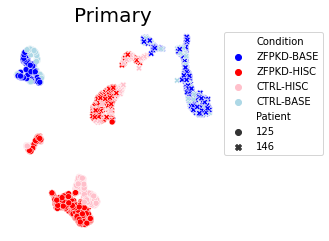

In [40]:
%matplotlib inline
color_labels = {}
for col, i in zip(['blue','red'],['BASE','HISC']):
    for shade,j in zip(['light',''],['CTRL','ZFPKD']):
        color_labels[i + '-' + j] = shade + col
        if color_labels[i + '-' + j] =='lightred':
            color_labels[i + '-' + j] = 'pink'
color_labels
            
fig, ax=plt.subplots(1,1, figsize=(3.8,3.8))

# Add missing keys
color_labels['ZFPKD-HISC'] = 'red'  
color_labels['ZFPKD-BASE'] = 'blue'  
color_labels['CTRL-BASE'] = 'lightblue'  
color_labels['CTRL-HISC'] = 'pink'  

ind1 = adata.obs.Tumor_Site=='Primary'
ind2 = adata.obs.Culture_Media!='Dedifferentiated'
ind = ind1.values & ind2.values

adata1 = adata[ind,:]

umap = adata1.obsm['X_umap']
plot_df = adata1.obs.loc[:,['Patient','Culture_Media','ZFP_Expression']]
plot_df['x'] = umap[:,0].tolist()
plot_df['y'] = umap[:,1].tolist()
plot_df['Condition'] = plot_df.ZFP_Expression.astype(str) + '-' + plot_df.Culture_Media.astype(str)

g = sns.scatterplot(data=plot_df, x='x',y='y', style='Patient', hue='Condition',
                    markers = {'125': 'o', '146': 'X'}, 
                    palette = color_labels, ax=ax)
ax.set_axis_off()
ax.legend(bbox_to_anchor=(1,1), loc='upper left')
ax.set_title('Primary',fontsize=20)

In [ ]:
# Read in the single-cell post-processed combined adata and metacells post-processed combined adata
adata_sc_hvg = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_post_hvg/adata.filteredmultiplex.combined.hvg_5000.h5ad')
adata_meta_hvg = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/metacells_noscvi/adata.post.combined.h5ad')

In [ ]:
adata

In [ ]:
hvg_info = adata.var["highly_variable"]
meta_hvg = adata.var_names[hvg_info]
print(meta_hvg)

In [ ]:
adata_sc_hvg

In [ ]:
hvg_info = adata_sc_hvg.var["highly_variable"]
sc_hvg = adata_sc_hvg.var_names[hvg_info]
print(sc_hvg)

In [ ]:
overlap = sc_hvg.intersection(meta_hvg)
overlap

In [22]:
adata_sc_hvg = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_post_hvg/adata.combined.hvg_5000.h5ad')

In [23]:
# Check if there are any var_names starting with "HTO"
hto_genes = [gene for gene in adata_sc_hvg.var_names if gene.startswith('HTO')]
print(hto_genes)

['HTO-1', 'HTO-2', 'HTO-3']


In [25]:
# Check if there are any var_names starting with "HTO"
tsb_genes = [gene for gene in adata_sc_hvg.var_names if gene.startswith('TSB0')]
print(tsb_genes)

['TSB0251', 'TSB0252', 'TSB0253']


In [28]:
# Check if genes start with 'HTO'
hashtag_genes = [gene for gene in adata_sc_hvg.raw.var_names if gene.startswith('HTO')]
print(hashtag_genes)

# Check if genes start with 'TSB0'
tsb0_genes = [gene for gene in adata_sc_hvg.raw.var_names if gene.startswith('TSB0')]
print(tsb0_genes)

['HTO-1', 'HTO-2', 'HTO-3']
['TSB0251', 'TSB0252', 'TSB0253']


In [33]:
import pandas as pd

# Replace 'features.tsv.gz' with the actual file path
file_path = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/raw.multiplex/125P_BASE_IGO_14730_4/raw_feature_bc_matrix/features.tsv.gz'

# Read the file into a DataFrame
features_df = pd.read_csv(file_path, sep='\t', compression='gzip', header=None, names=['Gene'])

# Check if 'Multiplexing Capture' exists in the 'Gene' column
contains_multiplexing_capture = features_df['Gene'].str.contains('Multiplexing Capture', case=False)

# Print or use the result
print(features_df[contains_multiplexing_capture])

                                 Gene
TSB0251 TSB0251  Multiplexing Capture
TSB0252 TSB0252  Multiplexing Capture
TSB0253 TSB0253  Multiplexing Capture


### There are some multiplexing capture genes. When do they pop up?

### From cell bender output...

In [39]:
from cellbender.remove_background.downstream import anndata_from_h5
adata_cellbender = anndata_from_h5('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_cellbender/125P_BASE_IGO_14730_4/cellbender/output/cellbender.125P_BASE_IGO_14730_4.combined.h5')

/home/forsythb/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


In [50]:
print(adata_cellbender.var_names[adata_cellbender.var_names.str.startswith('TSB0')])
print(adata_cellbender.var_names[adata_cellbender.var_names.str.startswith('HTO')])

Index(['TSB0251', 'TSB0252', 'TSB0253'], dtype='object', name='gene_name')
Index([], dtype='object', name='gene_name')


### From concatenation output...

In [51]:
adata_concat = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_concat/adata.combined.h5ad')

In [56]:
print(adata_concat.var_names[adata_concat.var_names.str.startswith('TSB0')])
print(adata_concat.var_names[adata_concat.var_names.str.startswith('HTO')])

Index(['TSB0251', 'TSB0252', 'TSB0253'], dtype='object', name='gene_name')
Index(['HTO-1', 'HTO-2', 'HTO-3'], dtype='object', name='gene_name')


In [8]:
# Read in the metacells post-processed combined adata
adata_meta_hvg = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/metacells_noscvi/adata.post.combined.h5ad')

In [9]:
print(adata_meta_hvg.var_names[adata_meta_hvg.var_names.str.startswith('ZFP')])

Index(['ZFP1', 'ZFP14', 'ZFP2', 'ZFP28', 'ZFP3', 'ZFP30', 'ZFP36', 'ZFP36L1',
       'ZFP36L2', 'ZFP37', 'ZFP41', 'ZFP42', 'ZFP57', 'ZFP62', 'ZFP64',
       'ZFP69', 'ZFP69B', 'ZFP82', 'ZFP90', 'ZFP91', 'ZFP92', 'ZFPL1', 'ZFPM1',
       'ZFPM2', 'ZFPM2-AS1'],
      dtype='object', name='gene_name')


In [10]:
adata_sc_hvg = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_post_hvg/adata.filteredmultiplex.combined.hvg_5000.h5ad')

In [15]:
adata_sc_hvg.obs

,background_fraction,cell_probability,cell_size,droplet_efficiency,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,...,log10_original_total_counts,mito_frac,Patient,Tumor_Site,Culture_Media,ZFP_Expression,Replicate,Batch,Sample,phenograph
146P_BASE_shZFP36L2_3_TTAGGGTCAGTAACGG-1,0.028566,0.999801,8876.052734,1.340430,3138,8.051660,9862,9.196546,29.132022,40.701683,...,3.993965,0.048874,146,Primary,BASE,ZFP_KD,1,5,146_P_BASE_ZFPKD_1,5
KG146Li_BASE_shZFP36L2_4_CGTTAGACACGTAACT-1,0.116489,0.999945,9333.853516,0.757079,1427,7.264030,5294,8.574518,68.530412,71.269362,...,3.723784,0.373064,146,Metastatic,BASE,ZFP_KD,2,2,146_M_BASE_ZFPKD_2,14
146P_BASE_shCTRL_AGGTGTTCATACAGGG-1,0.075099,1.000000,8071.062012,0.780837,2078,7.639642,4914,8.500047,35.978836,44.342694,...,3.691435,0.087098,146,Primary,BASE,CTRL,1,5,146_P_BASE_CTRL_1,0
146P_BASE_shZFP36L2_4_CCTCTAGGTCGCATTA-1,0.015017,0.999890,10491.471680,1.244276,4046,8.305731,11282,9.331052,21.680553,30.269456,...,4.052386,0.042723,146,Primary,BASE,ZFP_KD,2,5,146_P_BASE_ZFPKD_2,0
125P_HISC_shZFP36L2_3_GTTGTCCTCCACTGGG-1,0.023782,0.999968,12623.271484,1.163859,3437,8.142645,12520,9.435163,43.170927,51.829073,...,4.097604,0.066134,125,Primary,HISC,ZFP_KD,1,1,125_P_HISC_ZFPKD_1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125P_HISC_shZFP36L2_4_TTCGGTCTCCGTTGGG-1,0.032047,0.999999,11612.512695,1.116061,3433,8.141481,10813,9.288597,33.764913,44.696199,...,4.033946,0.053824,125,Primary,HISC,ZFP_KD,2,1,125_P_HISC_ZFPKD_2,3
146P_HISC_shZFP36L2_4_ACAAAGATCATCACTT-1,0.021406,0.999804,12408.628906,1.137434,4342,8.376321,11932,9.387063,30.263158,36.188401,...,4.076713,0.100067,146,Primary,HISC,ZFP_KD,2,6,146_P_HISC_ZFPKD_2,13
146P_BASE_shZFP36L2_3_TCAGGTAAGTTTAGGA-1,0.030128,0.999998,8865.494141,1.121671,2957,7.992269,8241,9.016998,31.707317,41.730373,...,3.915980,0.036403,146,Primary,BASE,ZFP_KD,1,5,146_P_BASE_ZFPKD_1,0
146P_HISC_shZFP36L2_3_TCATCATAGATCGGTG-1,0.018190,0.999955,13321.495117,1.290548,4366,8.381832,14735,9.598049,30.580251,40.190024,...,4.168350,0.047506,146,Primary,HISC,ZFP_KD,1,6,146_P_HISC_ZFPKD_1,1


/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) inst

Text(0.5, 1.0, 'Primary')

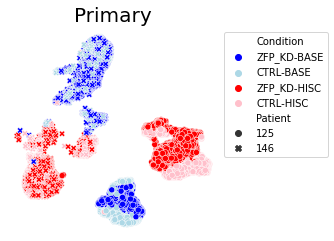

In [18]:
%matplotlib inline
color_labels = {}
for col, i in zip(['blue','red'],['BASE','HISC']):
    for shade,j in zip(['light',''],['CTRL','ZFP_KD']):
        color_labels[i + '-' + j] = shade + col
        if color_labels[i + '-' + j] =='lightred':
            color_labels[i + '-' + j] = 'pink'
color_labels
            
fig, ax=plt.subplots(1,1, figsize=(3.8,3.8))

# Add missing keys
color_labels['ZFP_KD-HISC'] = 'red'  
color_labels['ZFP_KD-BASE'] = 'blue'  
color_labels['CTRL-BASE'] = 'lightblue'  
color_labels['CTRL-HISC'] = 'pink'  

ind1 = adata_sc_hvg.obs.Tumor_Site=='Primary'
ind2 = adata_sc_hvg.obs.Culture_Media!='Dedifferentiated'
ind = ind1.values & ind2.values

adata1 = adata_sc_hvg[ind,:]

umap = adata1.obsm['X_umap']
plot_df = adata1.obs.loc[:,['Patient','Culture_Media','ZFP_Expression']]
plot_df['x'] = umap[:,0].tolist()
plot_df['y'] = umap[:,1].tolist()
plot_df['Condition'] = plot_df.ZFP_Expression.astype(str) + '-' + plot_df.Culture_Media.astype(str)

g = sns.scatterplot(data=plot_df, x='x',y='y', style='Patient', hue='Condition',
                    markers = {125: 'o', 146: 'X'}, 
                    palette = color_labels, ax=ax)
ax.set_axis_off()
ax.legend(bbox_to_anchor=(1,1), loc='upper left')
ax.set_title('Primary',fontsize=20)

In [2]:
adata_concat = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/metacells/adata.combined.h5ad')

In [3]:
adata_concat

AnnData object with n_obs × n_vars = 3934 × 32491
    obs: 'Patient', 'Tumor_Type', 'Culture_Media', 'ZFP_Expression', 'Sample_Name', 'Batch'
    layers: 'raw'

### Plotting UMAPs

In [5]:
adata_sc_hvg = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_post_hvg/adata.filteredmultiplex.combined.hvg_5000.h5ad')

In [13]:
adata_sc_hvg.obs

,background_fraction,cell_probability,cell_size,droplet_efficiency,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,...,log10_original_total_counts,mito_frac,Patient,Tumor_Site,Culture_Media,ZFP_Expression,Replicate,Batch,Sample,phenograph
146P_BASE_shZFP36L2_3_TTAGGGTCAGTAACGG-1,0.028566,0.999801,8876.052734,1.340430,3138,8.051660,9862,9.196546,29.132022,40.701683,...,3.993965,0.048874,146,Primary,BASE,ZFP_KD,1,5,146_P_BASE_ZFPKD_1,5
KG146Li_BASE_shZFP36L2_4_CGTTAGACACGTAACT-1,0.116489,0.999945,9333.853516,0.757079,1427,7.264030,5294,8.574518,68.530412,71.269362,...,3.723784,0.373064,146,Metastatic,BASE,ZFP_KD,2,2,146_M_BASE_ZFPKD_2,14
146P_BASE_shCTRL_AGGTGTTCATACAGGG-1,0.075099,1.000000,8071.062012,0.780837,2078,7.639642,4914,8.500047,35.978836,44.342694,...,3.691435,0.087098,146,Primary,BASE,CTRL,1,5,146_P_BASE_CTRL_1,0
146P_BASE_shZFP36L2_4_CCTCTAGGTCGCATTA-1,0.015017,0.999890,10491.471680,1.244276,4046,8.305731,11282,9.331052,21.680553,30.269456,...,4.052386,0.042723,146,Primary,BASE,ZFP_KD,2,5,146_P_BASE_ZFPKD_2,0
125P_HISC_shZFP36L2_3_GTTGTCCTCCACTGGG-1,0.023782,0.999968,12623.271484,1.163859,3437,8.142645,12520,9.435163,43.170927,51.829073,...,4.097604,0.066134,125,Primary,HISC,ZFP_KD,1,1,125_P_HISC_ZFPKD_1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125P_HISC_shZFP36L2_4_TTCGGTCTCCGTTGGG-1,0.032047,0.999999,11612.512695,1.116061,3433,8.141481,10813,9.288597,33.764913,44.696199,...,4.033946,0.053824,125,Primary,HISC,ZFP_KD,2,1,125_P_HISC_ZFPKD_2,3
146P_HISC_shZFP36L2_4_ACAAAGATCATCACTT-1,0.021406,0.999804,12408.628906,1.137434,4342,8.376321,11932,9.387063,30.263158,36.188401,...,4.076713,0.100067,146,Primary,HISC,ZFP_KD,2,6,146_P_HISC_ZFPKD_2,13
146P_BASE_shZFP36L2_3_TCAGGTAAGTTTAGGA-1,0.030128,0.999998,8865.494141,1.121671,2957,7.992269,8241,9.016998,31.707317,41.730373,...,3.915980,0.036403,146,Primary,BASE,ZFP_KD,1,5,146_P_BASE_ZFPKD_1,0
146P_HISC_shZFP36L2_3_TCATCATAGATCGGTG-1,0.018190,0.999955,13321.495117,1.290548,4366,8.381832,14735,9.598049,30.580251,40.190024,...,4.168350,0.047506,146,Primary,HISC,ZFP_KD,1,6,146_P_HISC_ZFPKD_1,1


{'BASE-CTRL': 'lightblue', 'BASE-ZFP_KD': 'blue', 'HISC-CTRL': 'pink', 'HISC-ZFP_KD': 'red'}


/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) inst

Text(0.5, 1.0, 'Primary')

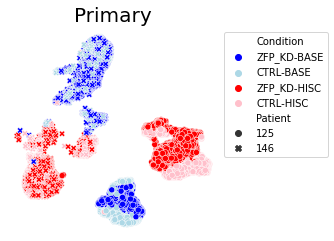

In [19]:
%matplotlib inline
color_labels = {}
for col, i in zip(['blue','red'],['BASE','HISC']):
    for shade,j in zip(['light',''],['CTRL','ZFP_KD']):
        color_labels[i + '-' + j] = shade + col
        if color_labels[i + '-' + j] =='lightred':
            color_labels[i + '-' + j] = 'pink'
print(color_labels)
            
fig, ax=plt.subplots(1,1, figsize=(3.8,3.8))

# Add missing keys
color_labels['CTRL-BASE'] = 'lightblue'  
color_labels['ZFP_KD-BASE'] = 'blue'  
color_labels['CTRL-HISC'] = 'pink'  
color_labels['ZFP_KD-HISC'] = 'red'  

ind1 = adata_sc_hvg.obs.Tumor_Site=='Primary'
ind2 = adata_sc_hvg.obs.Culture_Media!='Dedifferentiated'
ind = ind1.values & ind2.values

adata1 = adata_sc_hvg[ind,:]

umap = adata1.obsm['X_umap']
plot_df = adata1.obs.loc[:,['Patient','Culture_Media','ZFP_Expression']]
plot_df['x'] = umap[:,0].tolist()
plot_df['y'] = umap[:,1].tolist()
plot_df['Condition'] = plot_df.ZFP_Expression.astype(str) + '-' + plot_df.Culture_Media.astype(str)

g = sns.scatterplot(data=plot_df, x='x',y='y', style='Patient', hue='Condition',
                    markers = {125: 'o', 146: 'X'}, 
                    palette = color_labels, ax=ax)
ax.set_axis_off()
ax.legend(bbox_to_anchor=(1,1), loc='upper left')
ax.set_title('Primary',fontsize=20)

In [2]:
adata_sc_hvg_new = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_post_hvg/adata.filteredmultiplex.combined.hvg_5000.h5ad')

In [3]:
adata_sc_hvg_old = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_post_hvg/adata.combined.hvg_5000.h5ad')

In [4]:
hvg_info_old = adata_sc_hvg_old.var["highly_variable"]
sc_hvg_old = adata_sc_hvg_old.var_names[hvg_info_old]

hvg_info_new = adata_sc_hvg_new.var["highly_variable"]
sc_hvg_new = adata_sc_hvg_new.var_names[hvg_info_new]

In [5]:
overlap = sc_hvg_old.intersection(sc_hvg_new)
overlap

Index(['A2ML1', 'AADACL2', 'AADACL2-AS1', 'AADAT', 'AARD', 'ABAT', 'ABCA1',
       'ABCA13', 'ABCA4', 'ABCA9-AS1',
       ...
       'ZNF99', 'ZNRF2', 'ZNRF3', 'ZPLD1', 'ZPR1', 'ZRANB2-AS2', 'ZSCAN12',
       'ZSCAN23', 'ZSCAN32', 'ZWINT'],
      dtype='object', name='gene_name', length=4929)

In [9]:
adata_sc_hvg_new.var.highly_variable.sum()

5000